In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score

## Box plots of ID in image space

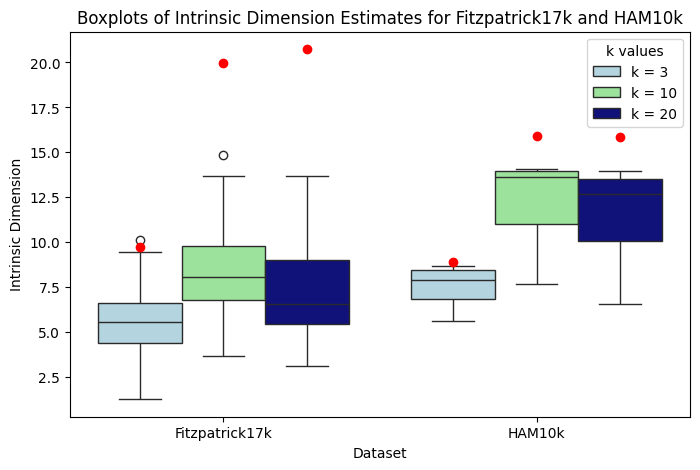

In [5]:
# Define k values
ks = [3, 10, 20]  

fitz_class_3 = np.load('./estimates/Fitzpatrick17k/image_space/class_wise/3/estimates.npy', allow_pickle=True).item()
fitz_class_10 = np.load('./estimates/Fitzpatrick17k/image_space/class_wise/10/estimates.npy', allow_pickle=True).item()
fitz_class_20 = np.load('./estimates/Fitzpatrick17k/image_space/class_wise/20/estimates.npy', allow_pickle=True).item()
fitz_class_wise = fitz_class_3 | fitz_class_10 | fitz_class_20

ham10k_class_wise = {3: [8.70, 8.48, 8.39, 5.88, 7.81, 7.91, 5.61],
                10: [13.63, 13.55, 14.07, 8.5, 13.93, 14.03, 7.66],
                20: [12.7, 12.53, 13.57, 7.61, 13.42, 13.94, 6.59]}

fitz_3 = np.load('./estimates/Fitzpatrick17k/image_space/all_classes/3/estimates.npy', allow_pickle=True).item()
fitz_10 = np.load('./estimates/Fitzpatrick17k/image_space/all_classes/10/estimates.npy', allow_pickle=True).item()
fitz_20 = np.load('./estimates/Fitzpatrick17k/image_space/all_classes/20/estimates.npy', allow_pickle=True).item()
fitz_all = fitz_3 | fitz_10 | fitz_20

ham10k_all = {3: [8.92], 10: [15.89], 20: [15.86]}

# Create a DataFrame
df_list = []
for k in ks:
    df_list.append(pd.DataFrame({
        "Intrinsic Dimension": np.concatenate([fitz_class_wise[k], ham10k_class_wise[k]]),
        "Dataset": ["Fitzpatrick17k"] * len(fitz_class_wise[k]) + ["HAM10k"] * len(ham10k_class_wise[k]),
        "k": [f"k = {k}"] * (len(fitz_class_wise[k]) + len(ham10k_class_wise[k]))
    }))
df = pd.concat(df_list)

# Create the box plot
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x="Dataset", y="Intrinsic Dimension", hue="k", data=df, palette=["lightblue", "lightgreen", "darkblue"])

# Get base x-tick positions (centers of CIFAR-10 and HAM10k)
x_ticks = np.array(ax.get_xticks())  

# Compute offsets for each k using Seaborn's internal spacing
num_k = len(ks)
box_group_width = 0.8  # Total width of grouped boxes (Seaborn default)
spacing = np.linspace(-box_group_width / 3, box_group_width / 3, num_k)  # Compute exact offsets

# Plot the red dots at the correct locations
for i, k in enumerate(ks):
    plt.scatter(
        x_ticks + spacing[i],  # Shift red dots precisely to center of each k box
        [fitz_all[k], ham10k_all[k]],  
        color="red",
        zorder=3,
        label=None
    )

# Labels and legend
plt.ylabel("Intrinsic Dimension")
plt.legend(title="k values")
plt.title("Boxplots of Intrinsic Dimension Estimates for Fitzpatrick17k and HAM10k")

plt.show()

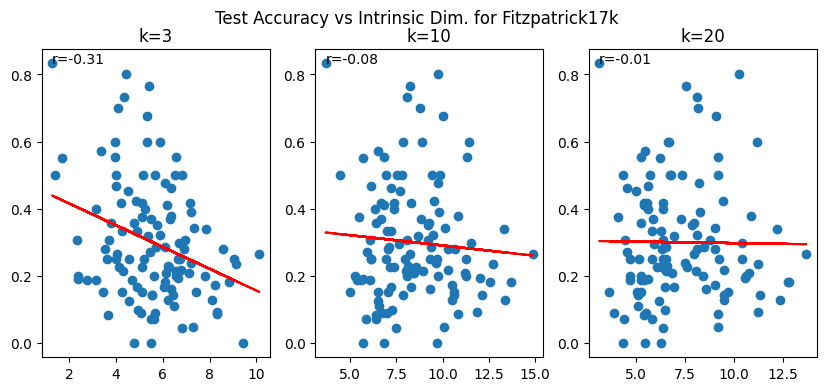

In [6]:
fitz_test_df = np.load('../contrastive-skin-lesion/inference_results/Fitzpatrick17k/low/vit_2.npy', allow_pickle=True).item()['test']
fitz_accs = recall_score(fitz_test_df['label'], fitz_test_df['model_pred'], average=None)

fig, ax = plt.subplots(1, 3, figsize=(10,4))
for idx, k in enumerate(ks):
    x = fitz_class_wise[k]
    y = fitz_accs
    ax[idx].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[idx].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[idx].plot(x, regression_line, color="red")
    ax[idx].set_title(f"k={k}")
fig.suptitle("Test Accuracy vs Intrinsic Dim. for Fitzpatrick17k")
plt.show()

## Box plots of ID in embedding space

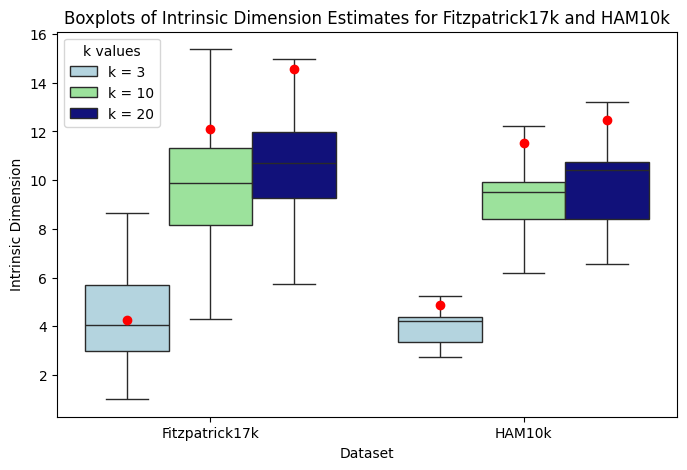

In [4]:
# Define k values
ks = [3, 10, 20]  

fitz_class_3 = np.load('./estimates/Fitzpatrick17k/embedding_space/vit_2/class_wise/3/estimates.npy', allow_pickle=True).item()
fitz_class_10 = np.load('./estimates/Fitzpatrick17k/embedding_space/vit_2/class_wise/10/estimates.npy', allow_pickle=True).item()
fitz_class_20 = np.load('./estimates/Fitzpatrick17k/embedding_space/vit_2/class_wise/20/estimates.npy', allow_pickle=True).item()
fitz_class_wise = fitz_class_3 | fitz_class_10 | fitz_class_20

ham10k_class_wise = {3: [4.55, 4.22, 4.24, 2.73, 3.56, 5.25, 3.12],
                10: [9.50, 9.97, 9.89, 6.17, 9.29, 12.21, 7.48],
                20: [9.46, 10.83, 10.63, 6.56, 10.43, 13.20, 7.33]}

fitz_3 = np.load('./estimates/Fitzpatrick17k/embedding_space/vit_2/all_classes/3/estimates.npy', allow_pickle=True).item()
fitz_10 = np.load('./estimates/Fitzpatrick17k/embedding_space/vit_2/all_classes/10/estimates.npy', allow_pickle=True).item()
fitz_20 = np.load('./estimates/Fitzpatrick17k/embedding_space/vit_2/all_classes/20/estimates.npy', allow_pickle=True).item()
fitz_all = fitz_3 | fitz_10 | fitz_20

ham10k_all = {3: [4.86], 10: [11.54], 20: [12.46]}

# Create a DataFrame
df_list = []
for k in ks:
    df_list.append(pd.DataFrame({
        "Intrinsic Dimension": np.concatenate([fitz_class_wise[k], ham10k_class_wise[k]]),
        "Dataset": ["Fitzpatrick17k"] * len(fitz_class_wise[k]) + ["HAM10k"] * len(ham10k_class_wise[k]),
        "k": [f"k = {k}"] * (len(fitz_class_wise[k]) + len(ham10k_class_wise[k]))
    }))
df = pd.concat(df_list)

# Create the box plot
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x="Dataset", y="Intrinsic Dimension", hue="k", data=df, palette=["lightblue", "lightgreen", "darkblue"])

# Get base x-tick positions (centers of CIFAR-10 and HAM10k)
x_ticks = np.array(ax.get_xticks())  

# Compute offsets for each k using Seaborn's internal spacing
num_k = len(ks)
box_group_width = 0.8  # Total width of grouped boxes (Seaborn default)
spacing = np.linspace(-box_group_width / 3, box_group_width / 3, num_k)  # Compute exact offsets

# Plot the red dots at the correct locations
for i, k in enumerate(ks):
    plt.scatter(
        x_ticks + spacing[i],  # Shift red dots precisely to center of each k box
        [fitz_all[k], ham10k_all[k]],  
        color="red",
        zorder=3,
        label=None
    )

# Labels and legend
plt.ylabel("Intrinsic Dimension")
plt.legend(title="k values")
plt.title("Boxplots of Intrinsic Dimension Estimates for Fitzpatrick17k and HAM10k")

plt.show()

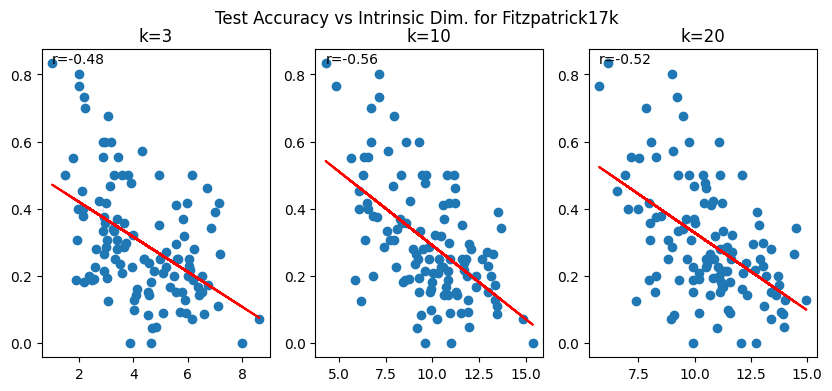

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(10,4))
for idx, k in enumerate(ks):
    x = fitz_class_wise[k]
    y = fitz_accs
    ax[idx].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[idx].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[idx].plot(x, regression_line, color="red")
    ax[idx].set_title(f"k={k}")
fig.suptitle("Test Accuracy vs Intrinsic Dim. for Fitzpatrick17k")
plt.show()

<Axes: ylabel='Count'>

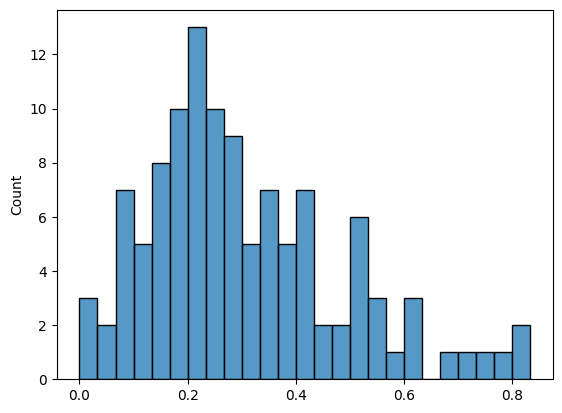

In [11]:
sns.histplot(fitz_accs, bins=25)